<a href="https://colab.research.google.com/github/kotishtrivedii/PayShield-AI/blob/main/payshieldai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn plotly shap joblib

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import shap
import joblib

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
np.random.seed(42)

N = 30000

df = pd.DataFrame({
    "transaction_id": [f"TXN{i:07d}" for i in range(1, N + 1)],

    "customer_id": [
        f"CUST{np.random.randint(1000, 9999)}"
        for _ in range(N)
    ],

    "amount": np.round(
        np.random.lognormal(mean=7.2, sigma=1.0, size=N),
        2
    ),

    "failed_attempts": np.random.poisson(0.4, N),

    "transactions_last_1h": np.random.poisson(1.5, N),

    "transactions_last_24h": np.random.poisson(5, N),

    "account_age_days": np.random.randint(1, 2500, N),

    "is_new_device": np.random.binomial(1, 0.12, N),

    "is_location_changed": np.random.binomial(1, 0.10, N),

    "is_international": np.random.binomial(1, 0.08, N),

    "night_transaction": np.random.binomial(1, 0.18, N)
})

df.head()

,transaction_id,customer_id,amount,failed_attempts,transactions_last_1h,transactions_last_24h,account_age_days,is_new_device,is_location_changed,is_international,night_transaction
0,TXN0000001,CUST8270,1235.74,2,4,6,1810,0,0,0,0
1,TXN0000002,CUST1860,285.31,1,1,6,621,0,0,0,0
2,TXN0000003,CUST6390,1636.66,0,4,5,1570,0,0,0,0
3,TXN0000004,CUST6191,1243.70,0,2,4,1214,1,0,0,0
4,TXN0000005,CUST6734,306.79,1,2,5,39,0,0,0,0


In [ ]:
risk_signal = (
    0.8 * (df["amount"] > df["amount"].quantile(0.90)).astype(int)
    + 1.0 * df["failed_attempts"]
    + 0.5 * df["transactions_last_1h"]
    + 0.15 * df["transactions_last_24h"]
    + 1.5 * df["is_new_device"]
    + 1.3 * df["is_location_changed"]
    + 1.0 * df["is_international"]
    + 0.6 * df["night_transaction"]
    - 0.0004 * df["account_age_days"]
)

probability = 1 / (1 + np.exp(-(risk_signal - 4.0)))

df["is_fraud"] = np.random.binomial(1, probability)

print("Dataset created!")
print("Rows:", len(df))
print("Fraud transactions:", df["is_fraud"].sum())
print("Fraud percentage:", round(df["is_fraud"].mean() * 100, 2), "%")

Dataset created!
Rows: 30000
Fraud transactions: 5170
Fraud percentage: 17.23 %


In [ ]:
print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()

Dataset shape:
(30000, 12)

Columns:
['transaction_id', 'customer_id', 'amount', 'failed_attempts', 'transactions_last_1h', 'transactions_last_24h', 'account_age_days', 'is_new_device', 'is_location_changed', 'is_international', 'night_transaction', 'is_fraud']

Missing values:
transaction_id           0
customer_id              0
amount                   0
failed_attempts          0
transactions_last_1h     0
transactions_last_24h    0
account_age_days         0
is_new_device            0
is_location_changed      0
is_international         0
night_transaction        0
is_fraud                 0
dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         30000 non-null  object 
 1   customer_id            30000 non-null  object 
 2   amount                 30000 non-null  f

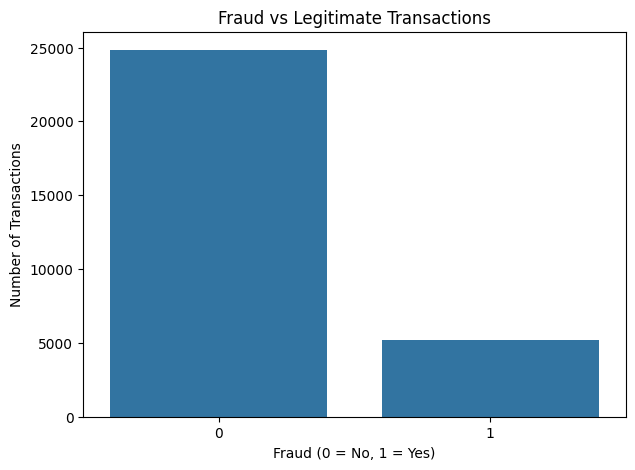

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="is_fraud"
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions")

plt.show()

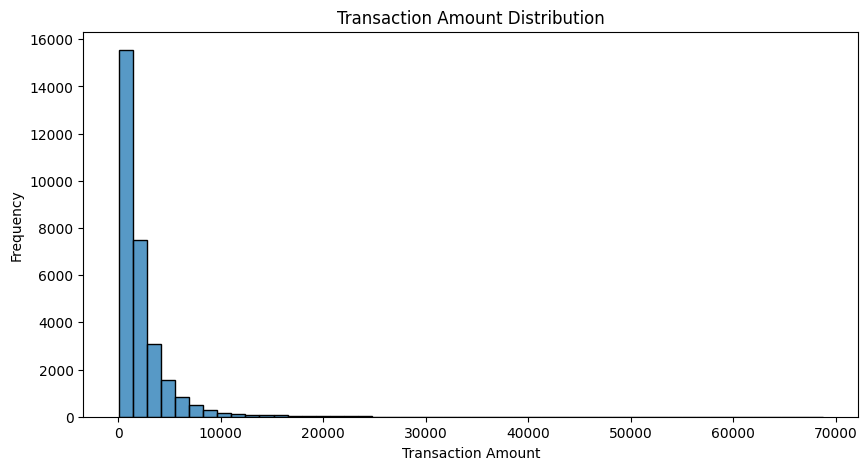

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="amount",
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [ ]:
fraud_device = pd.crosstab(
    df["is_new_device"],
    df["is_fraud"],
    normalize="index"
) * 100

print(fraud_device)

is_fraud               0          1
is_new_device                      
0              85.362154  14.637846
1              63.911846  36.088154


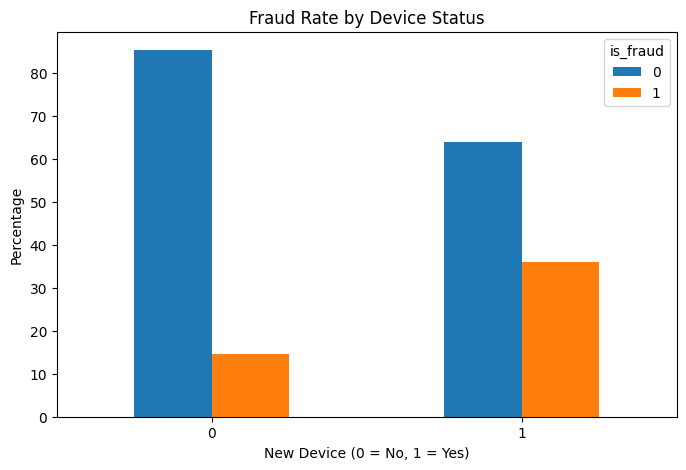

In [ ]:
fraud_device.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Fraud Rate by Device Status")
plt.xlabel("New Device (0 = No, 1 = Yes)")
plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

In [ ]:
FEATURES = [
    "amount", "failed_attempts", "transactions_last_1h",
    "transactions_last_24h", "account_age_days",
    "is_new_device", "is_location_changed",
    "is_international", "night_transaction"
]

X = df[FEATURES]
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(24000, 9) (6000, 9)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

iso = IsolationForest(
    n_estimators=150,
    contamination=0.05,
    random_state=42
)

iso.fit(X_train)

print("Both models trained!")

Both models trained!


In [ ]:
pred = rf.predict(X_test)
prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test, pred,
    target_names=["Legitimate", "Fraud"],
    zero_division=0
))

print("ROC-AUC:", round(roc_auc_score(y_test, prob), 4))

              precision    recall  f1-score   support

  Legitimate       0.89      0.85      0.87      4966
       Fraud       0.42      0.52      0.46      1034

    accuracy                           0.79      6000
   macro avg       0.66      0.68      0.67      6000
weighted avg       0.81      0.79      0.80      6000

ROC-AUC: 0.7711


In [ ]:
anomaly = -iso.decision_function(X_test)

anomaly = (
    (anomaly - anomaly.min()) /
    (anomaly.max() - anomaly.min()) * 100
)

results = X_test.copy()
results["fraud_probability"] = prob * 100
results["anomaly_score"] = anomaly

results["risk_score"] = (
    0.7 * results["fraud_probability"] +
    0.3 * results["anomaly_score"]
).clip(0, 100).round(2)

results["risk_level"] = pd.cut(
    results["risk_score"],
    bins=[-1, 30, 70, 100],
    labels=["LOW", "MEDIUM", "HIGH"]
)

results.head()

,amount,failed_attempts,transactions_last_1h,transactions_last_24h,account_age_days,is_new_device,is_location_changed,is_international,night_transaction,fraud_probability,anomaly_score,risk_score,risk_level
8274,1288.49,0,0,6,2487,0,0,0,0,8.506818,21.004164,12.26,LOW
28583,2641.99,0,2,4,43,0,0,0,0,32.507939,14.925109,27.23,LOW
23097,403.21,0,1,6,2356,0,0,0,0,16.661999,10.130847,14.70,LOW
20895,520.22,1,2,6,2361,0,0,1,0,43.246511,49.975839,45.27,MEDIUM
6020,953.99,0,1,4,596,0,0,0,0,19.999007,4.541690,15.36,LOW


In [ ]:
def analyze(row):
    factors = []

    if row["amount"] > df["amount"].quantile(.9):
        factors.append("Unusually high amount")
    if row["failed_attempts"] >= 3:
        factors.append("Multiple failed attempts")
    if row["transactions_last_1h"] >= 5:
        factors.append("High transaction frequency")
    if row["is_new_device"]:
        factors.append("New device")
    if row["is_location_changed"]:
        factors.append("Location changed")
    if row["is_international"]:
        factors.append("International transaction")

    score = row["risk_score"]

    action = (
        "APPROVE" if score < 30 else
        "ADDITIONAL VERIFICATION" if score < 70 else
        "MANUAL REVIEW" if score < 90 else
        "TEMPORARILY BLOCK"
    )

    return factors or ["No major risk factors"], action

In [ ]:
test = results.iloc[0]

factors, action = analyze(test)

print("🛡️ PAYSHIELD AI")
print("-" * 35)
print("Risk Score:", test["risk_score"], "/100")
print("Risk Level:", test["risk_level"])
print("Fraud Probability:", round(test["fraud_probability"], 2), "%")
print("Action:", action)

print("\nRisk Factors:")
for f in factors:
    print("•", f)

🛡️ PAYSHIELD AI
-----------------------------------
Risk Score: 12.26 /100
Risk Level: LOW
Fraud Probability: 8.51 %
Action: APPROVE

Risk Factors:
• No major risk factors


In [ ]:
sample = pd.DataFrame([{
    "amount": 50000,
    "failed_attempts": 5,
    "transactions_last_1h": 8,
    "transactions_last_24h": 25,
    "account_age_days": 20,
    "is_new_device": 1,
    "is_location_changed": 1,
    "is_international": 1,
    "night_transaction": 1
}])

prob = rf.predict_proba(sample)[0][1] * 100
anom = -iso.decision_function(sample)[0]

anom = (
    (anom - anomaly.min()) /
    (anomaly.max() - anomaly.min()) * 100
)

score = np.clip(
    .7 * prob + .3 * anom,
    0, 100
)

print("Risk Score:", round(score, 2), "/100")
print("Fraud Probability:", round(prob, 2), "%")

Risk Score: 48.13 /100
Fraud Probability: 68.67 %


In [ ]:
joblib.dump(
    {
        "rf": rf,
        "iso": iso,
        "features": FEATURES,
        "anomaly_min": anomaly.min(),
        "anomaly_max": anomaly.max()
    },
    "payshield_model.pkl"
)

print("Model saved!")

Model saved!


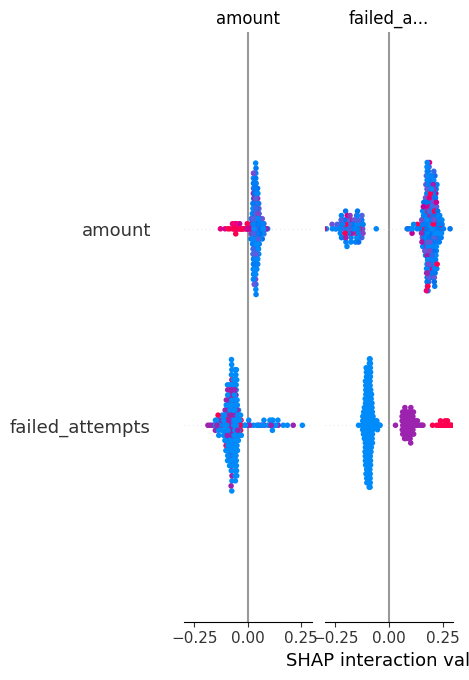

In [ ]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test.iloc[:300])

shap.summary_plot(
    shap_values,
    X_test.iloc[:300]
)

In [ ]:
!streamlit run app.py &>/content/streamlit.log &

In [ ]:
!pip -q install pyngrok

In [ ]:
!ls -la

total 25996
drwxr-xr-x 1 root root     4096 Aug 25 15:26 .
drwxr-xr-x 1 root root     4096 Aug 25 15:16 ..
drwxr-xr-x 4 root root     4096 Aug 20 13:29 .config
-rw-r--r-- 1 root root 26595379 Aug 25 15:24 payshield_model.pkl
drwxr-xr-x 1 root root     4096 Aug 20 13:29 sample_data
-rw-r--r-- 1 root root       48 Aug 25 15:28 streamlit.log


In [ ]:
!pip -q install streamlit pyngrok

import subprocess
import time
from pyngrok import ngrok

# ==============================
# PAYSHIELD AI STREAMLIT APP
# ==============================

app_code = r'''
import streamlit as st

st.set_page_config(
    page_title="PayShield AI",
    page_icon="🛡️",
    layout="wide"
)

# ---------- CSS ----------
st.markdown("""
<style>
.main {
    background-color: #0f172a;
}

.block-container {
    padding-top: 2rem;
}

.risk-high {
    padding: 25px;
    border-radius: 15px;
    background: #3b1111;
    border: 2px solid #ef4444;
    text-align: center;
}

.risk-medium {
    padding: 25px;
    border-radius: 15px;
    background: #3b2f0b;
    border: 2px solid #f59e0b;
    text-align: center;
}

.risk-low {
    padding: 25px;
    border-radius: 15px;
    background: #0b3b24;
    border: 2px solid #22c55e;
    text-align: center;
}

.factor {
    padding: 12px;
    margin: 6px 0;
    border-radius: 8px;
    background: #1e293b;
}
</style>
""", unsafe_allow_html=True)

# ---------- HEADER ----------

st.title("🛡️ PayShield AI")
st.subheader("Intelligent Payment Risk & Fraud Detection System")

st.write(
    "Analyze payment transactions using behavioral risk signals "
    "and generate an explainable 0–100 risk score."
)

st.divider()

# ---------- SIDEBAR ----------

st.sidebar.header("💳 Transaction Details")

amount = st.sidebar.number_input(
    "Transaction Amount (₹)",
    min_value=1.0,
    value=45000.0,
    step=500.0
)

average_amount = st.sidebar.number_input(
    "Customer Average Transaction (₹)",
    min_value=1.0,
    value=4200.0,
    step=100.0
)

failed_attempts = st.sidebar.number_input(
    "Failed Attempts",
    min_value=0,
    max_value=20,
    value=4
)

transactions_last_hour = st.sidebar.number_input(
    "Transactions in Last Hour",
    min_value=0,
    max_value=50,
    value=7
)

is_new_device = st.sidebar.selectbox(
    "Device",
    ["Known Device", "New Device"]
)

location_change = st.sidebar.selectbox(
    "Location",
    ["Normal Location", "New Location"]
)

transaction_hour = st.sidebar.slider(
    "Transaction Hour",
    min_value=0,
    max_value=23,
    value=2
)

is_international = st.sidebar.selectbox(
    "International Transaction",
    ["No", "Yes"]
)

# ---------- RISK ENGINE ----------

if st.button("🔍 ANALYZE TRANSACTION", use_container_width=True):

    risk_score = 0
    factors = []

    # Amount anomaly
    amount_ratio = amount / average_amount

    if amount_ratio >= 10:
        risk_score += 30
        factors.append(
            f"Transaction amount is {amount_ratio:.1f}× the customer's average"
        )
    elif amount_ratio >= 5:
        risk_score += 20
        factors.append(
            f"Transaction amount is {amount_ratio:.1f}× the customer's average"
        )
    elif amount_ratio >= 3:
        risk_score += 10
        factors.append(
            f"Transaction amount is {amount_ratio:.1f}× the customer's average"
        )

    # Failed attempts
    if failed_attempts >= 4:
        risk_score += 20
        factors.append("Multiple failed payment attempts detected")
    elif failed_attempts >= 2:
        risk_score += 10
        factors.append("Repeated failed payment attempts")

    # Transaction velocity
    if transactions_last_hour >= 7:
        risk_score += 20
        factors.append("Very high transaction velocity")
    elif transactions_last_hour >= 4:
        risk_score += 10
        factors.append("Elevated transaction velocity")

    # Device
    if is_new_device == "New Device":
        risk_score += 15
        factors.append("New device detected")

    # Location
    if location_change == "New Location":
        risk_score += 10
        factors.append("Location anomaly detected")

    # Time
    if transaction_hour >= 0 and transaction_hour <= 5:
        risk_score += 10
        factors.append("Transaction occurred during unusual hours")

    # International
    if is_international == "Yes":
        risk_score += 5
        factors.append("International transaction")

    # Maximum 100
    risk_score = min(risk_score, 100)

    # Risk classification
    if risk_score >= 75:
        risk_level = "HIGH"
        recommendation = "MANUAL REVIEW / TEMPORARILY HOLD"
    elif risk_score >= 40:
        risk_level = "MEDIUM"
        recommendation = "ADDITIONAL VERIFICATION"
    else:
        risk_level = "LOW"
        recommendation = "APPROVE"

    # ---------- RESULT ----------

    st.subheader("📊 Risk Assessment")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("Risk Score", f"{risk_score}/100")

    with col2:
        st.metric("Risk Level", risk_level)

    with col3:
        st.metric("Amount", f"₹{amount:,.0f}")

    st.divider()

    # Risk banner
    if risk_level == "HIGH":

        st.markdown(
            f"""
            <div class="risk-high">
                <h1>🚨 HIGH RISK</h1>
                <h2>{risk_score}/100</h2>
                <p><b>Recommended Action:</b></p>
                <h3>{recommendation}</h3>
            </div>
            """,
            unsafe_allow_html=True
        )

    elif risk_level == "MEDIUM":

        st.markdown(
            f"""
            <div class="risk-medium">
                <h1>⚠️ MEDIUM RISK</h1>
                <h2>{risk_score}/100</h2>
                <p><b>Recommended Action:</b></p>
                <h3>{recommendation}</h3>
            </div>
            """,
            unsafe_allow_html=True
        )

    else:

        st.markdown(
            f"""
            <div class="risk-low">
                <h1>✅ LOW RISK</h1>
                <h2>{risk_score}/100</h2>
                <p><b>Recommended Action:</b></p>
                <h3>{recommendation}</h3>
            </div>
            """,
            unsafe_allow_html=True
        )

    st.divider()

    # ---------- RISK FACTORS ----------

    st.subheader("🔎 Why was this transaction flagged?")

    if factors:

        for i, factor in enumerate(factors, 1):
            st.markdown(
                f"""
                <div class="factor">
                    <b>{i}.</b> {factor}
                </div>
                """,
                unsafe_allow_html=True
            )

    else:
        st.success("No significant risk factors detected.")

    # ---------- TRANSACTION SUMMARY ----------

    st.divider()
    st.subheader("💳 Transaction Summary")

    summary_col1, summary_col2 = st.columns(2)

    with summary_col1:
        st.write(f"**Transaction Amount:** ₹{amount:,.2f}")
        st.write(f"**Customer Average:** ₹{average_amount:,.2f}")
        st.write(f"**Amount Ratio:** {amount_ratio:.2f}×")
        st.write(f"**Failed Attempts:** {failed_attempts}")

    with summary_col2:
        st.write(f"**Transactions / Hour:** {transactions_last_hour}")
        st.write(f"**Device:** {is_new_device}")
        st.write(f"**Location:** {location_change}")
        st.write(f"**Transaction Hour:** {transaction_hour}:00")

    # ---------- EXPLANATION ----------

    st.divider()
    st.subheader("🤖 AI Risk Explanation")

    if risk_level == "HIGH":

        st.error(
            f"This transaction received a risk score of {risk_score}/100. "
            "The combination of unusual transaction behavior, "
            "velocity, device/location signals, or failed attempts "
            "indicates that the payment requires immediate investigation."
        )

    elif risk_level == "MEDIUM":

        st.warning(
            f"This transaction received a risk score of {risk_score}/100. "
            "Some behavioral signals differ from the customer's normal "
            "pattern. Additional verification is recommended."
        )

    else:

        st.success(
            f"This transaction received a risk score of {risk_score}/100. "
            "The transaction is broadly consistent with the provided "
            "customer behavior and can be approved."
        )

st.divider()

st.caption(
    "PayShield AI • Explainable Payment Risk Intelligence • "
    "Prototype for AI Risk Manager"
)
'''

# Write app.py
with open("/content/app.py", "w") as f:
    f.write(app_code)

# Stop previous Streamlit/ngrok processes
ngrok.kill()

# Start Streamlit
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/content/app.py",
        "--server.port", "8501",
        "--server.address", "0.0.0.0",
        "--server.headless", "true"
    ],
    stdout=open("/content/streamlit.log", "w"),
    stderr=subprocess.STDOUT
)

# Give Streamlit time to start
time.sleep(7)

# ==============================
# NGROK
# ==============================

NGROK_TOKEN = "32k1eUGSw7Zrj98EM4y45cfOzQP_2Xexzb1sUfAjSeKb1dqeo"

ngrok.set_auth_token(NGROK_TOKEN)

public_url = ngrok.connect(8501, "http")

print("\n" + "=" * 60)
print("🛡️ PAYSHIELD AI IS LIVE")
print("=" * 60)
print(f"\n🌐 PUBLIC URL:\n\n{public_url}\n")
print("=" * 60)
print("Open the URL above in your browser.")
print("=" * 60)


🛡️ PAYSHIELD AI IS LIVE

🌐 PUBLIC URL:

NgrokTunnel: "https://2b52-34-32-252-32.ngrok-free.app" -> "http://localhost:8501"

Open the URL above in your browser.
